In [1]:
import requests

In [2]:
url = "https://en.wikipedia.org/wiki/Hyderabad"

In [3]:
page=requests.get(url,headers={"User-Agent": "Mozilla/5.0"})

In [4]:
page

<Response [200]>

In [5]:
page.status_code

200

In [6]:
page.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Hyderabad - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-fe

In [7]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from bs4 import BeautifulSoup
soup= BeautifulSoup(page.text,"html.parser")

In [8]:
print(soup.prettify()[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available" dir="ltr" lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Hyderabad - Wikipedia
  </title>
  <script>
   (function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enab

In [9]:
page.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Hyderabad - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-fe

In [10]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from bs4 import BeautifulSoup
soup= BeautifulSoup(page.text,"html.parser")

In [11]:
tables = soup.find_all("table", class_="wikitable")
len(tables)

3

In [12]:
print(tables[0].text[:500])



Historical affiliations



 Golconda Sultanate 1518–1687
(inception of Hyderabad city in 1591)
 Mughal Empire 1687–1724
 Nizam State 1724–1948
 Republic of India 1948 onwards
Hyderabad State 1948–1956
Andhra Pradesh 1956–2014
Telangana since 2014



In [13]:
print(tables[1].text[:500])



vteClimate data for Hyderabad (1991–2020, extremes 1951–2020)


Month

Jan

Feb

Mar

Apr

May

Jun

Jul

Aug

Sep

Oct

Nov

Dec

Year


Record high °C (°F)

35.9(96.6)

39.1(102.4)

42.2(108.0)

43.3(109.9)

44.5(112.1)

45.5(113.9)

38.0(100.4)

37.6(99.7)

36.5(97.7)

36.7(98.1)

34.0(93.2)

35.0(95.0)

45.5(113.9)


Mean daily maximum °C (°F)

28.6(83.5)

31.8(89.2)

35.2(95.4)

37.6(99.7)

38.8(101.8)

34.4(93.9)

30.5(86.9)

29.6(85.3)

30.1(86.2)

30.4(86.7)

28.8(83.8)

27.8(82.0)

32


In [16]:
data_dict = {}

for row in rows:
    cols = [col.text.strip() for col in row.find_all(["td","th"])]
    
    if len(cols) > 1:
        metric_name = cols[0]
        values = cols[1:13]
        
        data_dict[metric_name] = values

print(list(data_dict.keys()))

['Month', 'Record high °C (°F)', 'Mean daily maximum °C (°F)', 'Daily mean °C (°F)', 'Mean daily minimum °C (°F)', 'Record low °C (°F)', 'Average rainfall mm (inches)', 'Average precipitation days (≥ 0.3 mm)', 'Average rainy days', 'Average relative humidity (%) (at 17:30 IST)', 'Average dew point °C (°F)', 'Mean monthly sunshine hours', 'Mean daily sunshine hours', 'Average ultraviolet index']


In [17]:
for i, row in enumerate(rows[:5]):
    cols = [col.text.strip() for col in row.find_all(["td","th"])]
    print(i, cols)

0 ['vteClimate data for Hyderabad (1991–2020, extremes 1951–2020)']
1 ['Month', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Year']
2 ['Record high °C (°F)', '35.9(96.6)', '39.1(102.4)', '42.2(108.0)', '43.3(109.9)', '44.5(112.1)', '45.5(113.9)', '38.0(100.4)', '37.6(99.7)', '36.5(97.7)', '36.7(98.1)', '34.0(93.2)', '35.0(95.0)', '45.5(113.9)']
3 ['Mean daily maximum °C (°F)', '28.6(83.5)', '31.8(89.2)', '35.2(95.4)', '37.6(99.7)', '38.8(101.8)', '34.4(93.9)', '30.5(86.9)', '29.6(85.3)', '30.1(86.2)', '30.4(86.7)', '28.8(83.8)', '27.8(82.0)', '32.0(89.5)']
4 ['Daily mean °C (°F)', '22.8(73.0)', '25.4(77.7)', '28.8(83.8)', '31.4(88.5)', '33.2(91.8)', '29.7(85.5)', '27.2(81.0)', '26.4(79.5)', '26.8(80.2)', '26.2(79.2)', '24.1(75.4)', '22.2(72.0)', '27.0(80.6)']


In [15]:
climate_table = tables[1]
rows = climate_table.find_all("tr")

data = []

# Extract month names
header = [col.text.strip() for col in rows[1].find_all(["td","th"])]
months = header[1:13]
print("Months:", months)

Months: ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


In [18]:
def clean_temp(values):
    return [float(v.split("(")[0]) for v in values]

In [21]:
df = pd.DataFrame({
    "City": "Hyderabad",
    "Month": months,
    "Record_High_C": clean_temp(data_dict["Record high °C (°F)"]),
    "Mean_Max_C": clean_temp(data_dict["Mean daily maximum °C (°F)"]),
    "Daily_Mean_C": clean_temp(data_dict["Daily mean °C (°F)"]),
    "Mean_Min_C": clean_temp(data_dict["Mean daily minimum °C (°F)"]),
    "Record_Low_C": clean_temp(data_dict["Record low °C (°F)"]),
    "Rainfall_mm": clean_temp(data_dict["Average rainfall mm (inches)"]),
    "Rainy_Days": clean_temp(data_dict["Average precipitation days (≥ 0.3 mm)"]),
    "Humidity_%": clean_temp(data_dict["Average relative humidity (%) (at 17:30 IST)"]),
})

df

,City,Month,Record_High_C,Mean_Max_C,Daily_Mean_C,Mean_Min_C,Record_Low_C,Rainfall_mm,Rainy_Days,Humidity_%
0,Hyderabad,Jan,35.9,28.6,22.8,13.9,6.1,9.2,1.1,41.0
1,Hyderabad,Feb,39.1,31.8,25.4,15.5,8.9,10.2,1.0,33.0
2,Hyderabad,Mar,42.2,35.2,28.8,20.3,13.2,12.3,1.4,29.0
3,Hyderabad,Apr,43.3,37.6,31.4,24.1,16.0,27.2,3.7,30.0
4,Hyderabad,May,44.5,38.8,33.2,26.0,16.7,34.5,4.2,31.0
5,Hyderabad,Jun,45.5,34.4,29.7,23.9,17.8,113.8,10.9,52.0
6,Hyderabad,Jul,38.0,30.5,27.2,22.5,18.6,162.0,15.4,65.0
7,Hyderabad,Aug,37.6,29.6,26.4,22.0,18.7,203.9,16.3,70.0
8,Hyderabad,Sep,36.5,30.1,26.8,21.7,17.8,148.5,12.3,67.0
9,Hyderabad,Oct,36.7,30.4,26.2,20.0,11.7,113.9,7.6,59.0


In [22]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def scrape_city_climate(city):
    
    url = f"https://en.wikipedia.org/wiki/{city}"
    
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    tables = soup.find_all("table", class_="wikitable")
    
    climate_table = None
    
    
    for table in tables:
        if "Climate data" in table.text:
            climate_table = table
            break
    
    if climate_table is None:
        print(f"No climate table found for {city}")
        return None
    
    rows = climate_table.find_all("tr")
    
    header = [col.text.strip() for col in rows[1].find_all(["td","th"])]
    months = header[1:13]
    
    data_dict = {}
    
    for row in rows:
        cols = [col.text.strip() for col in row.find_all(["td","th"])]
        if len(cols) > 1:
            data_dict[cols[0]] = cols[1:13]
    
    def clean_temp(values):
        return [float(v.split("(")[0]) for v in values]
    
    def clean_numeric(values):
        cleaned = []
        for v in values:
            v = v.split("(")[0]
            v = v.replace("mm","").replace("%","").replace("days","").strip()
            cleaned.append(float(v))
        return cleaned
    
    try:
        df = pd.DataFrame({
            "City": city,
            "Month": months,
            "Record_High_C": clean_temp(data_dict[[k for k in data_dict if "Record high" in k][0]]),
            "Mean_Max_C": clean_temp(data_dict[[k for k in data_dict if "Mean daily maximum" in k][0]]),
            "Daily_Mean_C": clean_temp(data_dict[[k for k in data_dict if "Daily mean" in k][0]]),
            "Mean_Min_C": clean_temp(data_dict[[k for k in data_dict if "Mean daily minimum" in k][0]]),
            "Record_Low_C": clean_temp(data_dict[[k for k in data_dict if "Record low" in k][0]]),
            "Rainfall_mm": clean_numeric(data_dict[[k for k in data_dict if "rainfall" in k.lower()][0]]),
            "Humidity_%": clean_numeric(data_dict[[k for k in data_dict if "humidity" in k.lower()][0]]),
        })
        
        return df
    
    except:
        print(f"Some data missing for {city}")
        return None

In [60]:
cities = [
    "Hyderabad","Mumbai","Chennai","Bengaluru","Kolkata",
"Pune","Ahmedabad",
"Chandigarh","Jammu",
"Bhopal","Jabalpur","Raipur",
"Bhubaneswar",
"Guwahati","Itanagar",
"Surat",
"Nagpur","Aurangabad",
"Guwahati",
"Solapur",
"Tiruchirappalli","Panaji","Thiruvananthapuram",
"Silchar","Dibrugarh","Kozhikode","Kurnool","Anantapur","Port Blair",
"Nellore","Kakinada","Daltonganj","Dwarka","Akola","Machilipatnam","Minicoy"
]

all_data = []

for city in cities:
    print(city)
    df_city = scrape_city_climate(city)
    
    if df_city is not None:
        all_data.append(df_city)
    
    total_rows = sum(len(df) for df in all_data)
    
    if total_rows >= 600:
        break
        
    time.sleep(1)


Hyderabad
Mumbai
Chennai
Bengaluru
Kolkata
Pune
Ahmedabad
Chandigarh
Jammu
Bhopal
Jabalpur
Raipur
Bhubaneswar
Guwahati
Itanagar
Surat
Nagpur
Aurangabad
Guwahati
Solapur
Tiruchirappalli
Panaji
Thiruvananthapuram
Silchar
Dibrugarh
Kozhikode
Kurnool
Anantapur
Port Blair
Nellore
Kakinada
Daltonganj
Dwarka
Akola
Machilipatnam
Minicoy


In [61]:
final_df = pd.concat(all_data, ignore_index=True) 
final_df.shape

(432, 9)

In [62]:
final_df

,City,Month,Record_High_C,Mean_Max_C,Daily_Mean_C,Mean_Min_C,Record_Low_C,Rainfall_mm,Humidity_%
0,Hyderabad,Jan,35.9,28.6,22.8,13.9,6.1,9.2,41.0
1,Hyderabad,Feb,39.1,31.8,25.4,15.5,8.9,10.2,33.0
2,Hyderabad,Mar,42.2,35.2,28.8,20.3,13.2,12.3,29.0
3,Hyderabad,Apr,43.3,37.6,31.4,24.1,16.0,27.2,30.0
4,Hyderabad,May,44.5,38.8,33.2,26.0,16.7,34.5,31.0
...,...,...,...,...,...,...,...,...,...
427,Minicoy,Aug,33.4,31.1,28.3,25.5,19.7,208.8,80.0
428,Minicoy,Sep,33.2,31.1,28.3,25.5,20.3,162.6,79.0
429,Minicoy,Oct,33.3,31.2,28.2,25.2,19.4,172.6,79.0
430,Minicoy,Nov,33.2,31.2,28.1,25.0,17.2,143.1,78.0


In [63]:
final_df.to_csv("Climate_analysis.csv",index=False)

In [4]:
import pandas as pd

df = pd.read_csv("Climate_analysis.csv")
df

,City,Month,Record_High_C,Mean_Max_C,Daily_Mean_C,Mean_Min_C,Record_Low_C,Rainfall_mm,Humidity_%
0,Hyderabad,Jan,35.9,28.6,22.8,13.9,6.1,9.2,41.0
1,Hyderabad,Feb,39.1,31.8,25.4,15.5,8.9,10.2,33.0
2,Hyderabad,Mar,42.2,35.2,28.8,20.3,13.2,12.3,29.0
3,Hyderabad,Apr,43.3,37.6,31.4,24.1,16.0,27.2,30.0
4,Hyderabad,May,44.5,38.8,33.2,26.0,16.7,34.5,31.0
...,...,...,...,...,...,...,...,...,...
427,Minicoy,Aug,33.4,31.1,28.3,25.5,19.7,208.8,80.0
428,Minicoy,Sep,33.2,31.1,28.3,25.5,20.3,162.6,79.0
429,Minicoy,Oct,33.3,31.2,28.2,25.2,19.4,172.6,79.0
430,Minicoy,Nov,33.2,31.2,28.1,25.0,17.2,143.1,78.0


In [7]:
df.shape

(432, 9)

In [8]:
num_columns=df.shape[1]
print(num_columns)

9


In [10]:
num_rows=df.shape[0]
print(num_rows)

432


In [8]:
data_types=df.dtypes
print(data_types)

City              object
Month             object
Record_High_C    float64
Mean_Max_C       float64
Daily_Mean_C     float64
Mean_Min_C       float64
Record_Low_C     float64
Rainfall_mm      float64
Humidity_%       float64
dtype: object


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   City           432 non-null    object 
 1   Month          432 non-null    object 
 2   Record_High_C  432 non-null    float64
 3   Mean_Max_C     432 non-null    float64
 4   Daily_Mean_C   432 non-null    float64
 5   Mean_Min_C     432 non-null    float64
 6   Record_Low_C   432 non-null    float64
 7   Rainfall_mm    432 non-null    float64
 8   Humidity_%     432 non-null    float64
dtypes: float64(7), object(2)
memory usage: 30.5+ KB


In [10]:
df.columns

Index(['City', 'Month', 'Record_High_C', 'Mean_Max_C', 'Daily_Mean_C',
       'Mean_Min_C', 'Record_Low_C', 'Rainfall_mm', 'Humidity_%'],
      dtype='object')

In [11]:
df['City']

0      Hyderabad
1      Hyderabad
2      Hyderabad
3      Hyderabad
4      Hyderabad
         ...    
427      Minicoy
428      Minicoy
429      Minicoy
430      Minicoy
431      Minicoy
Name: City, Length: 432, dtype: object

In [12]:
df.sample()

,City,Month,Record_High_C,Mean_Max_C,Daily_Mean_C,Mean_Min_C,Record_Low_C,Rainfall_mm,Humidity_%
42,Bengaluru,Jul,33.3,28.3,24.2,20.1,16.1,116.4,65.0


In [13]:
over_all=df.describe()
over_all

,Record_High_C,Mean_Max_C,Daily_Mean_C,Mean_Min_C,Record_Low_C,Rainfall_mm,Humidity_%
count,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000
mean,38.581481,32.099537,26.862037,21.628472,13.967593,124.258102,60.226852
std,4.268590,3.753291,3.916186,4.770554,6.032019,154.979781,17.977930
min,27.200000,18.100000,12.700000,7.200000,0.000000,0.000000,19.000000
25%,35.600000,30.100000,25.100000,19.075000,9.400000,11.725000,47.000000
50%,38.200000,31.900000,27.500000,23.150000,15.800000,56.200000,65.000000
75%,41.100000,33.800000,29.225000,25.200000,19.100000,183.750000,75.000000
max,48.800000,43.100000,35.500000,28.700000,22.800000,955.200000,89.000000


In [39]:
df.index[0:50:6]

RangeIndex(start=0, stop=50, step=6)

In [14]:
len(df)

432

In [15]:
df["Record_High_C"]


0      35.9
1      39.1
2      42.2
3      43.3
4      44.5
       ... 
427    33.4
428    33.2
429    33.3
430    33.2
431    33.3
Name: Record_High_C, Length: 432, dtype: float64

In [50]:
df[["Record_High_C"]]


,Record_High_C
0,35.9
1,39.1
2,42.2
3,43.3
4,44.5
...,...
427,33.4
428,33.2
429,33.3
430,33.2


In [16]:
df.columns

Index(['City', 'Month', 'Record_High_C', 'Mean_Max_C', 'Daily_Mean_C',
       'Mean_Min_C', 'Record_Low_C', 'Rainfall_mm', 'Humidity_%'],
      dtype='object')

In [19]:
df.columns=['City', 'Month', 'Highest_Temp(C)', 'Mean_Max(C)', 'Daily Mean(C)',
       'Mean_Min(C)', 'Lowest_Temp(C)', 'Rainfall(mm)', 'Humidity(%)']

In [20]:
df

,City,Month,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%)
0,Hyderabad,Jan,35.9,28.6,22.8,13.9,6.1,9.2,41.0
1,Hyderabad,Feb,39.1,31.8,25.4,15.5,8.9,10.2,33.0
2,Hyderabad,Mar,42.2,35.2,28.8,20.3,13.2,12.3,29.0
3,Hyderabad,Apr,43.3,37.6,31.4,24.1,16.0,27.2,30.0
4,Hyderabad,May,44.5,38.8,33.2,26.0,16.7,34.5,31.0
...,...,...,...,...,...,...,...,...,...
427,Minicoy,Aug,33.4,31.1,28.3,25.5,19.7,208.8,80.0
428,Minicoy,Sep,33.2,31.1,28.3,25.5,20.3,162.6,79.0
429,Minicoy,Oct,33.3,31.2,28.2,25.2,19.4,172.6,79.0
430,Minicoy,Nov,33.2,31.2,28.1,25.0,17.2,143.1,78.0


In [21]:
month_avg = df.groupby("Month").mean(numeric_only=True)

In [22]:
month_avg

,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%)
Month,,,,,,,
Apr,42.427778,35.733333,29.830556,23.844444,15.002778,53.758333,47.916667
Aug,37.647222,31.483333,27.963889,24.541667,19.327778,274.275000,74.916667
Dec,33.988889,28.541667,22.288889,16.008333,7.897222,24.844444,59.027778
Feb,37.550000,30.294444,23.894444,17.277778,8.105556,15.827778,49.250000
Jan,34.108333,27.983333,21.708333,15.400000,7.097222,14.075000,55.250000
Jul,39.036111,32.019444,28.394444,24.891667,19.386111,319.544444,73.111111
Jun,42.666667,34.563889,30.038889,25.708333,19.072222,246.750000,63.305556
Mar,40.538889,33.422222,27.022222,20.586111,11.291667,25.672222,46.555556
May,43.636111,36.761111,31.338889,25.869444,17.458333,106.955556,51.333333


In [23]:
city_avg = df.groupby("City").mean(numeric_only=True)

In [24]:
city_avg

,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%)
City,,,,,,,
Ahmedabad,41.966667,34.416667,27.808333,21.225000,12.458333,65.300000,41.250000
Akola,41.775000,34.475000,27.783333,21.008333,10.641667,65.275000,42.500000
Anantapur,39.425000,34.400000,28.291667,22.183333,15.150000,55.300000,42.416667
Aurangabad,38.208333,32.533333,26.050000,19.250000,9.366667,67.641667,47.750000
Bengaluru,34.966667,29.783333,24.608333,19.416667,12.775000,89.816667,51.750000
Bhopal,39.158333,32.066667,25.533333,19.216667,10.358333,91.750000,44.666667
Bhubaneswar,40.508333,33.058333,27.708333,22.458333,14.375000,138.141667,69.666667
Chandigarh,37.633333,30.083333,24.241667,18.350000,8.250000,86.533333,51.500000
Chennai,39.216667,33.066667,29.083333,24.766667,17.916667,117.366667,68.833333


In [25]:
city_month = df.groupby(["City", "Month"]).mean(numeric_only=True)

In [72]:
city_month

Highest_Temp(C)  Mean_Max(C)  Daily Mean(C)  \
City            Month                                                
Ahmedabad       Apr               46.2         39.7           31.9   
                Aug               40.4         32.3           28.8   
                Dec               35.6         29.5           21.6   
                Feb               40.6         31.0           22.8   
                Jan               36.1         27.9           20.1   
...                                ...          ...            ...   
Tiruchirappalli Mar               42.2         36.0           29.7   
                May               43.3         38.2           32.0   
                Nov               36.7         30.6           26.6   
                Oct               38.9         33.1           28.3   
                Sep               40.6         35.4           29.9   

                       Mean_Min(C)  Lowest_Temp(C)  Rainfall(mm)  Humidity(%)  
City            Month                                                          
Ahmedabad       Apr           24.2            12.8           2.5         20.0  
                Aug           25.3            21.2         242.2         72.0  
                Dec           13.6             3.6           0.9         38.0  
                Feb           14.6             2.2           0.6         26.0  
                Jan           12.4             3.3           1.2         35.0  
...                            ...             ...           ...          ...  
Tiruchirappalli Mar           23.5            15.6           3.6         37.0  
                May           26.8            19.4          78.9         44.0  
                Nov           23.1            16.7         191.1         71.0  
                Oct           24.4            18.9         154.9         64.0  
                Sep           25.2            20.6         118.2         52.0  

[420 rows x 7 columns]

In [26]:
city_rain = df.groupby("City")["Rainfall(mm)"].sum().reset_index()

In [27]:
city_rain

,City,Rainfall(mm)
0,Ahmedabad,783.6
1,Akola,783.3
2,Anantapur,663.6
3,Aurangabad,811.7
4,Bengaluru,1077.8
5,Bhopal,1101.0
6,Bhubaneswar,1657.7
7,Chandigarh,1038.4
8,Chennai,1408.4
9,Daltonganj,1086.1


In [28]:
hot_cities = (
    df.groupby("City")["Mean_Max(C)"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

In [79]:
hot_cities

,City,Mean_Max(C)
0,Kurnool,34.641667
1,Tiruchirappalli,34.516667
2,Akola,34.475000
3,Nellore,34.450000
4,Ahmedabad,34.416667
5,Anantapur,34.400000
6,Solapur,34.341667
7,Nagpur,33.991667
8,Surat,33.200000
9,Machilipatnam,33.141667


In [29]:
df["city_avg_rainfall"] = df.groupby("City")["Rainfall(mm)"].transform("mean")

In [30]:
df["city_avg_rainfall"]

0       71.633333
1       71.633333
2       71.633333
3       71.633333
4       71.633333
          ...    
427    136.216667
428    136.216667
429    136.216667
430    136.216667
431    136.216667
Name: city_avg_rainfall, Length: 432, dtype: float64

In [31]:
df_sorted = df.sort_values(by="City", ascending=True)

In [32]:
df_sorted

,City,Month,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%),city_avg_rainfall
83,Ahmedabad,Dec,35.6,29.5,21.6,13.6,3.6,0.9,38.0,65.300000
77,Ahmedabad,Jun,47.2,39.0,33.3,27.7,19.4,84.3,44.0,65.300000
78,Ahmedabad,Jul,42.2,33.7,29.8,26.1,20.4,310.1,69.0,65.300000
79,Ahmedabad,Aug,40.4,32.3,28.8,25.3,21.2,242.2,72.0,65.300000
80,Ahmedabad,Sep,41.7,33.6,29.3,24.9,17.2,120.2,63.0,65.300000
...,...,...,...,...,...,...,...,...,...,...
247,Tiruchirappalli,Aug,40.6,36.0,30.5,25.8,20.6,87.7,48.0,71.683333
248,Tiruchirappalli,Sep,40.6,35.4,29.9,25.2,20.6,118.2,52.0,71.683333
249,Tiruchirappalli,Oct,38.9,33.1,28.3,24.4,18.9,154.9,64.0,71.683333
240,Tiruchirappalli,Jan,35.6,30.7,25.6,20.7,14.4,6.4,53.0,71.683333


In [33]:
df.sort_values(by="Month")

,City,Month,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%),city_avg_rainfall
267,Thiruvananthapuram,Apr,38.0,33.3,29.5,25.1,20.0,122.3,73.0,152.950000
327,Anantapur,Apr,43.2,39.9,32.9,25.7,18.3,32.0,25.0,55.300000
315,Kurnool,Apr,45.6,40.5,34.0,27.2,15.5,31.2,32.0,70.816667
303,Kozhikode,Apr,39.1,34.4,30.5,26.5,21.0,83.5,70.0,250.975000
39,Bengaluru,Apr,39.2,34.1,28.1,22.1,14.4,61.7,35.0,89.816667
...,...,...,...,...,...,...,...,...,...,...
284,Silchar,Sep,39.2,32.8,29.1,25.1,16.8,379.5,81.0,253.308333
44,Bengaluru,Sep,33.3,28.6,24.3,20.0,15.0,208.3,64.0,89.816667
344,Port Blair,Sep,35.4,29.5,26.6,23.7,16.8,505.2,89.0,259.433333
212,Aurangabad,Sep,37.0,30.2,25.8,21.5,12.6,172.4,69.0,67.641667


In [34]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)
df = df.sort_values(by=["City", "Month"])

In [35]:
df

,City,Month,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%),city_avg_rainfall
72,Ahmedabad,Jan,36.1,27.9,20.1,12.4,3.3,1.2,35.0,65.300000
73,Ahmedabad,Feb,40.6,31.0,22.8,14.6,2.2,0.6,26.0,65.300000
74,Ahmedabad,Mar,43.9,35.8,27.7,19.6,9.4,1.1,21.0,65.300000
75,Ahmedabad,Apr,46.2,39.7,31.9,24.2,12.8,2.5,20.0,65.300000
76,Ahmedabad,May,48.0,41.8,34.5,27.3,19.1,5.5,25.0,65.300000
...,...,...,...,...,...,...,...,...,...,...
247,Tiruchirappalli,Aug,40.6,36.0,30.5,25.8,20.6,87.7,48.0,71.683333
248,Tiruchirappalli,Sep,40.6,35.4,29.9,25.2,20.6,118.2,52.0,71.683333
249,Tiruchirappalli,Oct,38.9,33.1,28.3,24.4,18.9,154.9,64.0,71.683333
250,Tiruchirappalli,Nov,36.7,30.6,26.6,23.1,16.7,191.1,71.0,71.683333


In [36]:
df.sort_values(by="Highest_Temp(C)", ascending=False)

,City,Month,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%),city_avg_rainfall
376,Daltonganj,May,48.8,40.8,33.8,26.5,17.8,18.0,29.0,90.508333
76,Ahmedabad,May,48.0,41.8,34.5,27.3,19.1,5.5,25.0,65.300000
136,Raipur,May,47.9,41.8,35.1,27.8,14.4,23.8,26.0,107.525000
196,Nagpur,May,47.9,43.1,35.5,28.1,19.4,19.1,24.0,95.925000
412,Machilipatnam,May,47.8,37.8,32.9,28.2,17.8,43.3,64.0,89.583333
...,...,...,...,...,...,...,...,...,...,...
107,Jammu,Dec,28.5,21.1,14.9,8.7,0.9,21.9,69.0,116.833333
95,Chandigarh,Dec,28.5,22.1,15.1,8.0,0.0,22.3,62.0,86.533333
96,Jammu,Jan,28.0,18.1,12.7,7.3,0.5,67.9,66.0,116.833333
84,Chandigarh,Jan,27.7,18.2,12.7,7.2,0.0,37.8,65.0,86.533333


In [37]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Categorical Features:")
print(categorical_cols)
print("\nNumerical Features:")
print(numerical_cols)

Categorical Features:
Index(['City', 'Month'], dtype='object')

Numerical Features:
Index(['Highest_Temp(C)', 'Mean_Max(C)', 'Daily Mean(C)', 'Mean_Min(C)',
       'Lowest_Temp(C)', 'Rainfall(mm)', 'Humidity(%)', 'city_avg_rainfall'],
      dtype='object')


In [99]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Highest_Temp(C),432.0,38.581481,4.268590,27.200000,35.600000,38.200000,41.10000,48.800000
Mean_Max(C),432.0,32.099537,3.753291,18.100000,30.100000,31.900000,33.80000,43.100000
Daily Mean(C),432.0,26.862037,3.916186,12.700000,25.100000,27.500000,29.22500,35.500000
Mean_Min(C),432.0,21.628472,4.770554,7.200000,19.075000,23.150000,25.20000,28.700000
Lowest_Temp(C),432.0,13.967593,6.032019,0.000000,9.400000,15.800000,19.10000,22.800000
Rainfall(mm),432.0,124.258102,154.979781,0.000000,11.725000,56.200000,183.75000,955.200000
Humidity(%),432.0,60.226852,17.977930,19.000000,47.000000,65.000000,75.00000,89.000000
city_avg_rainfall,432.0,124.258102,65.062402,40.891667,71.670833,99.766667,143.74375,281.766667


In [38]:
stats_df = df[numerical_cols].agg([
    "mean",
    "median",
    "std",
    "var",
    "min",
    "max",
    "skew"
]).T

stats_df

,mean,median,std,var,min,max,skew
Highest_Temp(C),38.581481,38.200000,4.268590,18.220863,27.200000,48.800000,0.232223
Mean_Max(C),32.099537,31.900000,3.753291,14.087192,18.100000,43.100000,0.018005
Daily Mean(C),26.862037,27.500000,3.916186,15.336514,12.700000,35.500000,-0.776355
Mean_Min(C),21.628472,23.150000,4.770554,22.758190,7.200000,28.700000,-0.938064
Lowest_Temp(C),13.967593,15.800000,6.032019,36.385258,0.000000,22.800000,-0.665865
Rainfall(mm),124.258102,56.200000,154.979781,24018.732649,0.000000,955.200000,1.926226
Humidity(%),60.226852,65.000000,17.977930,323.205959,19.000000,89.000000,-0.584123
city_avg_rainfall,124.258102,99.766667,65.062402,4233.116100,40.891667,281.766667,1.085744


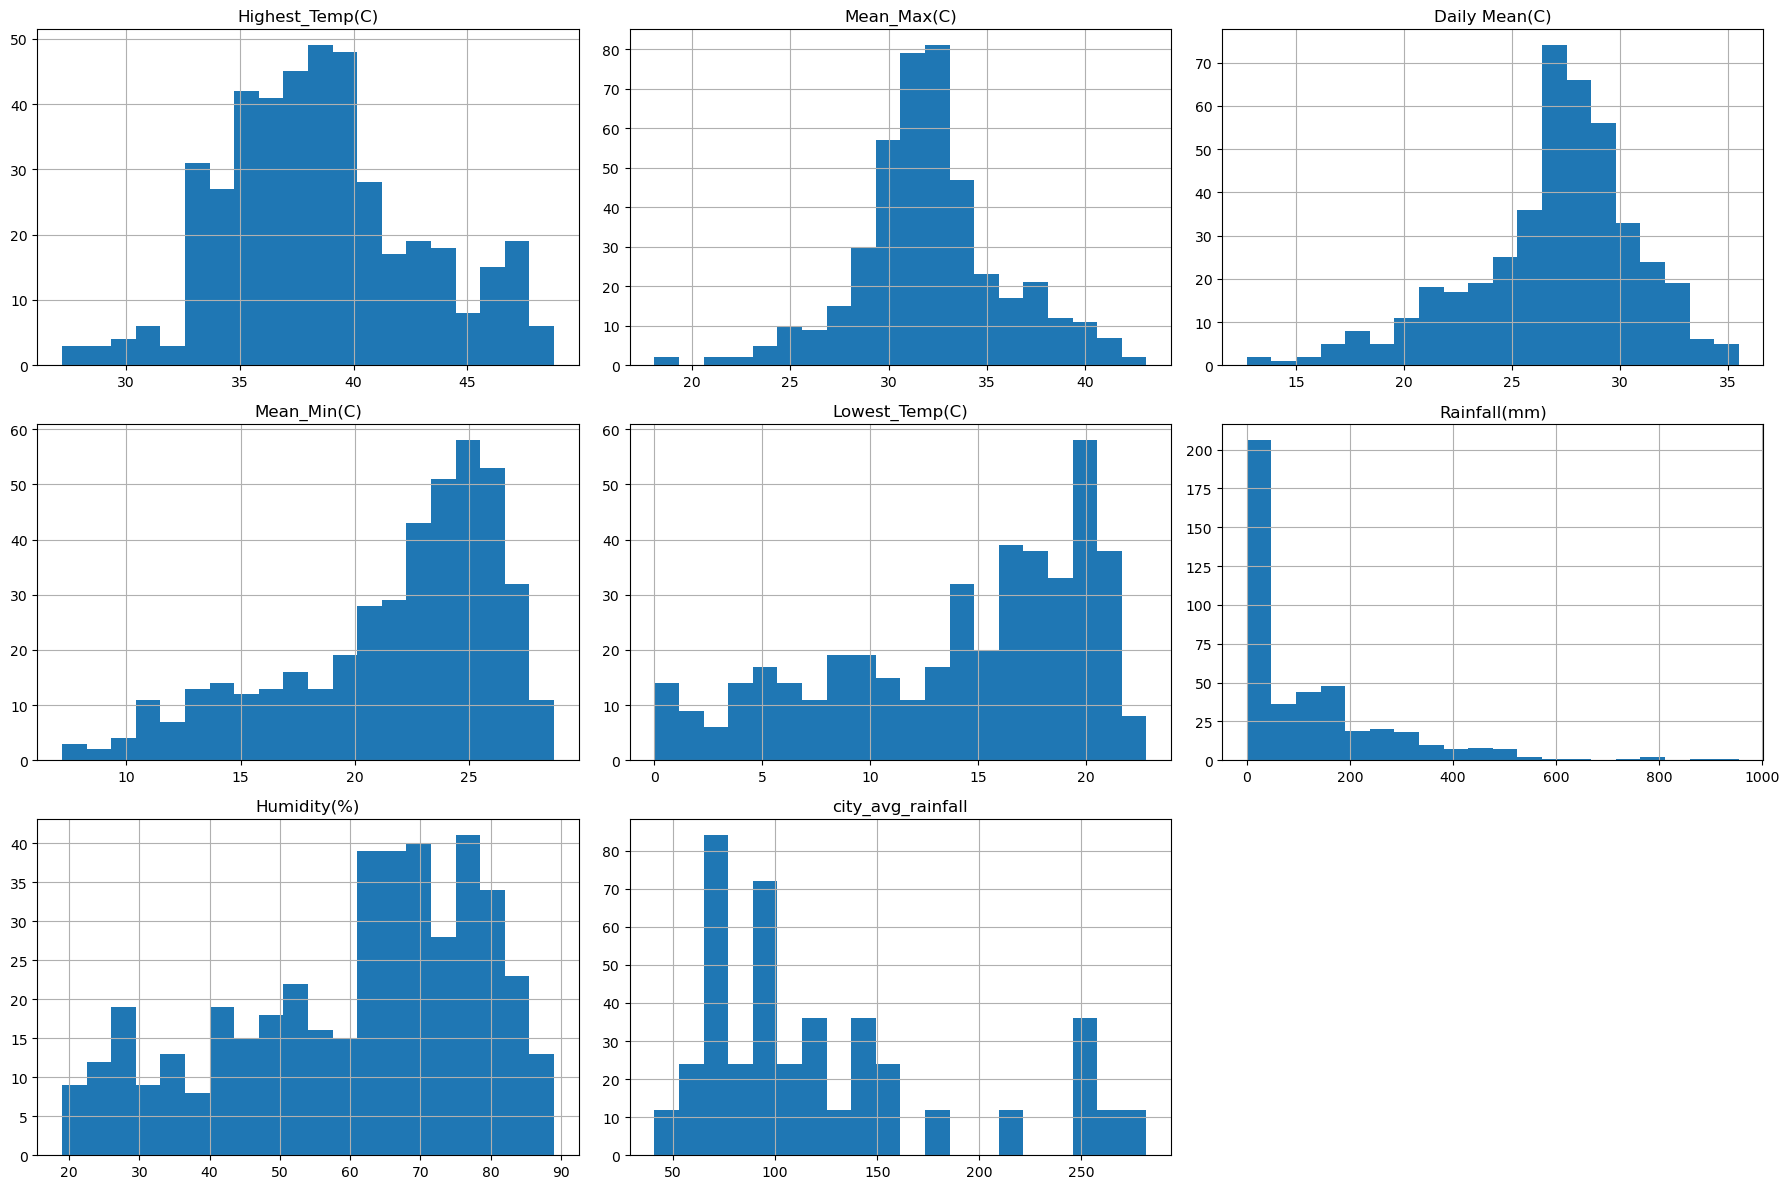

In [101]:
import matplotlib.pyplot as plt
df[numerical_cols].hist(figsize=(18,12), bins=20)
plt.tight_layout()
plt.show()

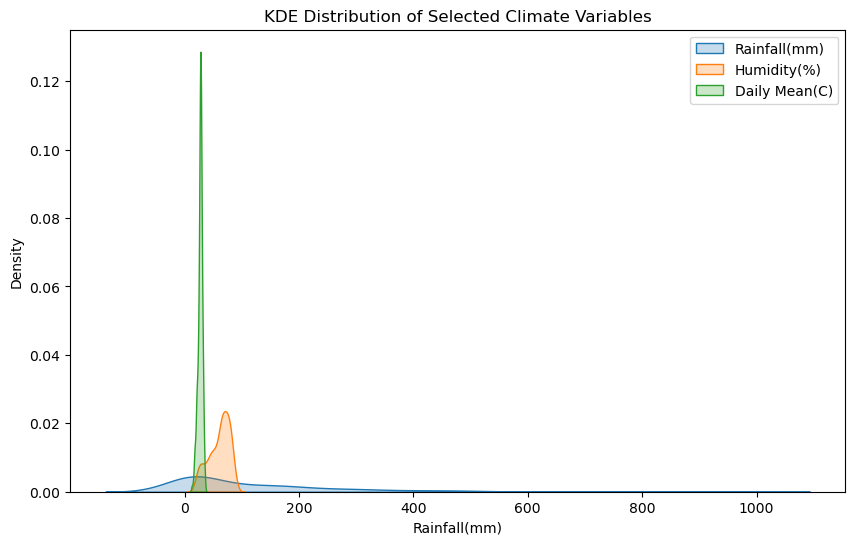

In [39]:
import seaborn as sns
plt.figure(figsize=(10,6))
for col in ["Rainfall(mm)", "Humidity(%)", "Daily Mean(C)"]:
    sns.kdeplot(df[col], label=col, fill=True)
plt.legend()
plt.title("KDE Distribution of Selected Climate Variables")
plt.show()

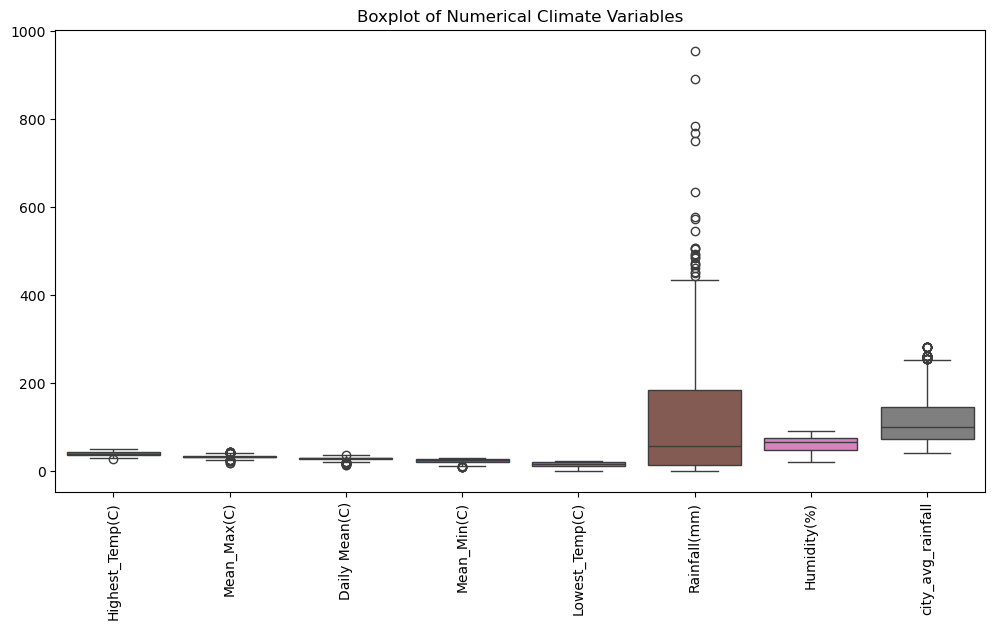

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Climate Variables")
plt.show()

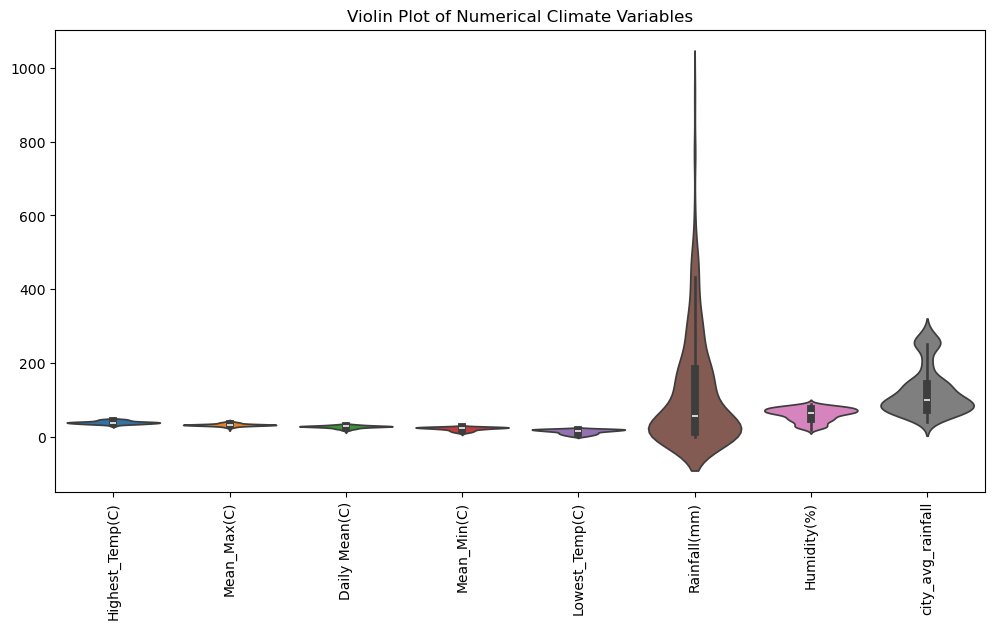

In [41]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Violin Plot of Numerical Climate Variables")
plt.show()

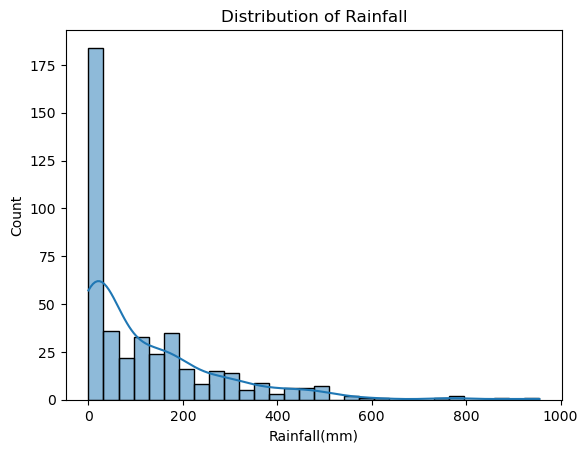

In [42]:
sns.histplot(df["Rainfall(mm)"], kde=True, bins=30)
plt.title("Distribution of Rainfall")
plt.show()

In [43]:
city_freq = df["City"].value_counts()
month_freq = df["Month"].value_counts()
city_percent = df["City"].value_counts(normalize=True) * 100
month_percent = df["Month"].value_counts(normalize=True) * 100
city_freq, city_percent, month_freq, month_percent

(City
 Guwahati              24
 Ahmedabad             12
 Kolkata               12
 Kurnool               12
 Machilipatnam         12
 Minicoy               12
 Mumbai                12
 Nagpur                12
 Nellore               12
 Panaji                12
 Port Blair            12
 Pune                  12
 Raipur                12
 Silchar               12
 Solapur               12
 Surat                 12
 Thiruvananthapuram    12
 Kozhikode             12
 Kakinada              12
 Akola                 12
 Jammu                 12
 Jabalpur              12
 Itanagar              12
 Hyderabad             12
 Dwarka                12
 Dibrugarh             12
 Daltonganj            12
 Chennai               12
 Chandigarh            12
 Bhubaneswar           12
 Bhopal                12
 Bengaluru             12
 Aurangabad            12
 Anantapur             12
 Tiruchirappalli       12
 Name: count, dtype: int64,
 City
 Guwahati              5.555556
 Ahmedabad        

In [45]:
df = df.drop_duplicates()

In [46]:
df

,City,Month,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%),city_avg_rainfall
72,Ahmedabad,Jan,36.1,27.9,20.1,12.4,3.3,1.2,35.0,65.300000
73,Ahmedabad,Feb,40.6,31.0,22.8,14.6,2.2,0.6,26.0,65.300000
74,Ahmedabad,Mar,43.9,35.8,27.7,19.6,9.4,1.1,21.0,65.300000
75,Ahmedabad,Apr,46.2,39.7,31.9,24.2,12.8,2.5,20.0,65.300000
76,Ahmedabad,May,48.0,41.8,34.5,27.3,19.1,5.5,25.0,65.300000
...,...,...,...,...,...,...,...,...,...,...
247,Tiruchirappalli,Aug,40.6,36.0,30.5,25.8,20.6,87.7,48.0,71.683333
248,Tiruchirappalli,Sep,40.6,35.4,29.9,25.2,20.6,118.2,52.0,71.683333
249,Tiruchirappalli,Oct,38.9,33.1,28.3,24.4,18.9,154.9,64.0,71.683333
250,Tiruchirappalli,Nov,36.7,30.6,26.6,23.1,16.7,191.1,71.0,71.683333


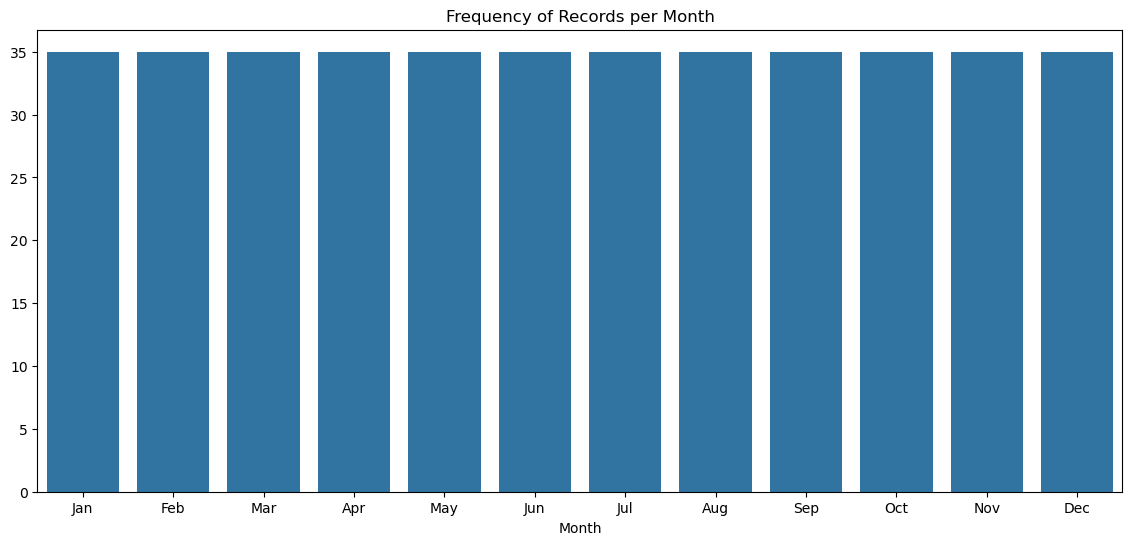

In [118]:
plt.figure(figsize=(14,6))
sns.barplot(x=month_freq.index, y=month_freq.values)
plt.title("Frequency of Records per Month")
plt.show()

In [120]:
city_rain = df.groupby("City")["Rainfall(mm)"].mean().sort_values(ascending=False)
city_rain

City
Itanagar              281.766667
Port Blair            259.433333
Silchar               253.308333
Kozhikode             250.975000
Panaji                248.683333
Dibrugarh             209.858333
Mumbai                184.450000
Thiruvananthapuram    152.950000
Kolkata               151.125000
Guwahati              141.283333
Bhubaneswar           138.141667
Minicoy               136.216667
Chennai               117.366667
Jammu                 116.833333
Jabalpur              113.983333
Raipur                107.525000
Surat                 103.608333
Nagpur                 95.925000
Kakinada               93.900000
Bhopal                 91.750000
Daltonganj             90.508333
Bengaluru              89.816667
Machilipatnam          89.583333
Nellore                88.950000
Chandigarh             86.533333
Tiruchirappalli        71.683333
Hyderabad              71.633333
Kurnool                70.816667
Pune                   70.108333
Aurangabad             67.641667
Ahmed

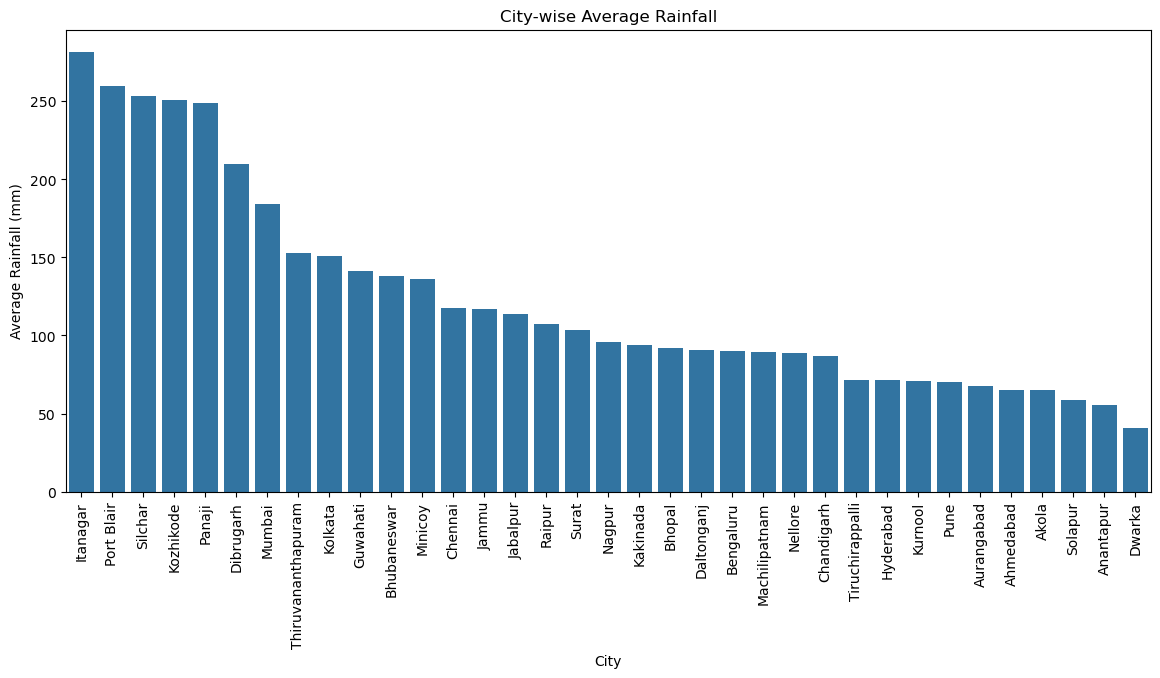

In [121]:
plt.figure(figsize=(14,6))
sns.barplot(x=city_rain.index, y=city_rain.values)
plt.xticks(rotation=90)
plt.ylabel("Average Rainfall (mm)")
plt.title("City-wise Average Rainfall")
plt.show()

In [122]:
month_temp = df.groupby("Month")["Daily Mean(C)"].mean()
month_temp = month_temp.reindex(month_order)  # Ensure chronological order
month_temp

C:\Users\praha\AppData\Local\Temp\ipykernel_36560\3298042962.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_temp = df.groupby("Month")["Daily Mean(C)"].mean()


Month
Jan    21.831429
Feb    24.005714
Mar    27.122857
Apr    29.948571
May    31.454286
Jun    30.077143
Jul    28.368571
Aug    27.920000
Sep    27.948571
Oct    27.157143
Nov    24.808571
Dec    22.382857
Name: Daily Mean(C), dtype: float64

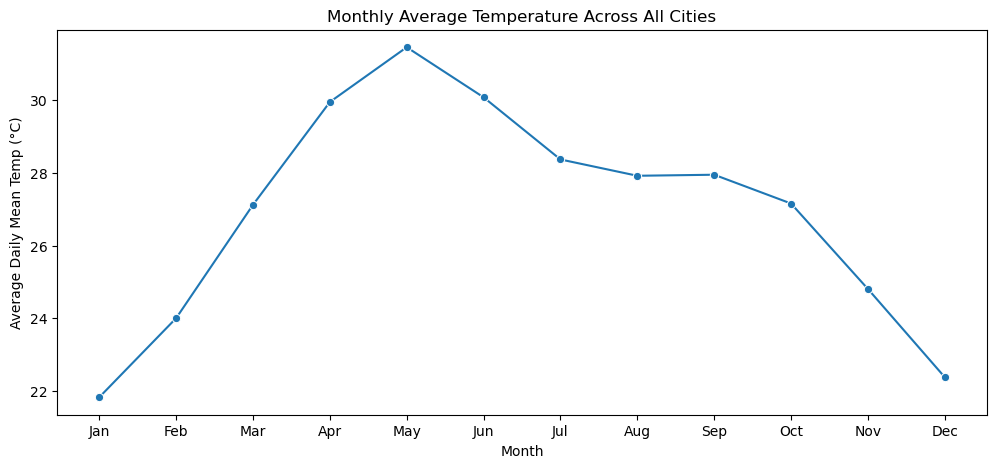

In [123]:
plt.figure(figsize=(12,5))
sns.lineplot(x=month_temp.index, y=month_temp.values, marker='o')
plt.ylabel("Average Daily Mean Temp (°C)")
plt.title("Monthly Average Temperature Across All Cities")
plt.show()

In [124]:
corr_matrix = df[numerical_cols].corr()
corr_matrix

,Highest_Temp(C),Mean_Max(C),Daily Mean(C),Mean_Min(C),Lowest_Temp(C),Rainfall(mm),Humidity(%),city_avg_rainfall
Highest_Temp(C),1.000000,0.887395,0.775267,0.583965,0.340993,-0.089112,-0.455969,-0.328960
Mean_Max(C),0.887395,1.000000,0.901168,0.695689,0.461648,-0.095626,-0.446789,-0.240903
Daily Mean(C),0.775267,0.901168,1.000000,0.934077,0.771566,0.182490,-0.067613,-0.096878
Mean_Min(C),0.583965,0.695689,0.934077,1.000000,0.916404,0.384633,0.254950,0.030183
Lowest_Temp(C),0.340993,0.461648,0.771566,0.916404,1.000000,0.518784,0.483909,0.177589
Rainfall(mm),-0.089112,-0.095626,0.182490,0.384633,0.518784,1.000000,0.616858,0.422705
Humidity(%),-0.455969,-0.446789,-0.067613,0.254950,0.483909,0.616858,1.000000,0.550110
city_avg_rainfall,-0.328960,-0.240903,-0.096878,0.030183,0.177589,0.422705,0.550110,1.000000


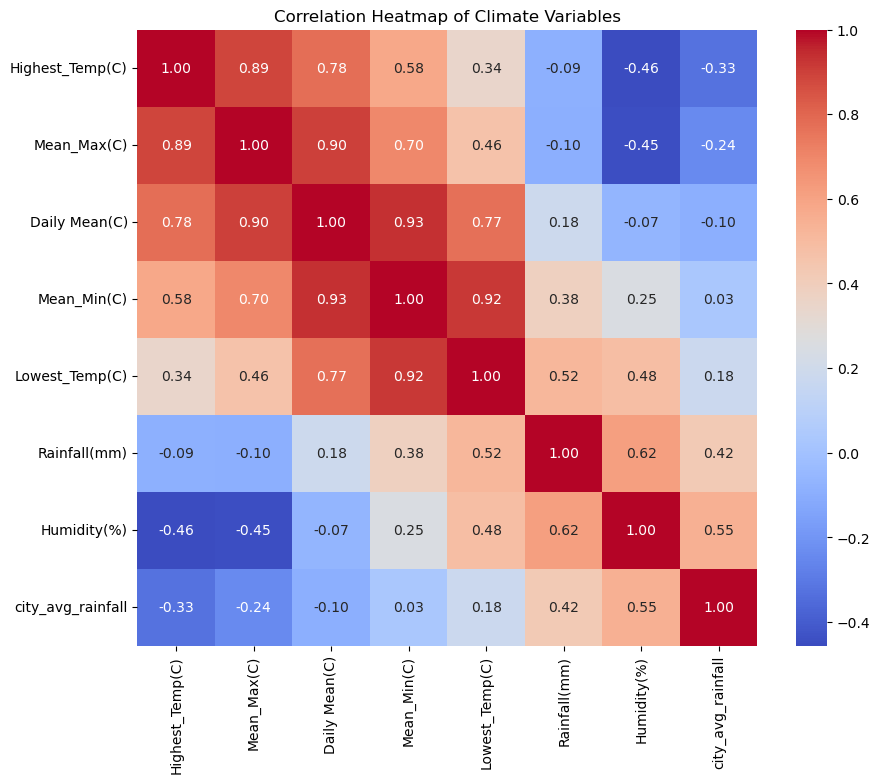

In [125]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Climate Variables")
plt.show()

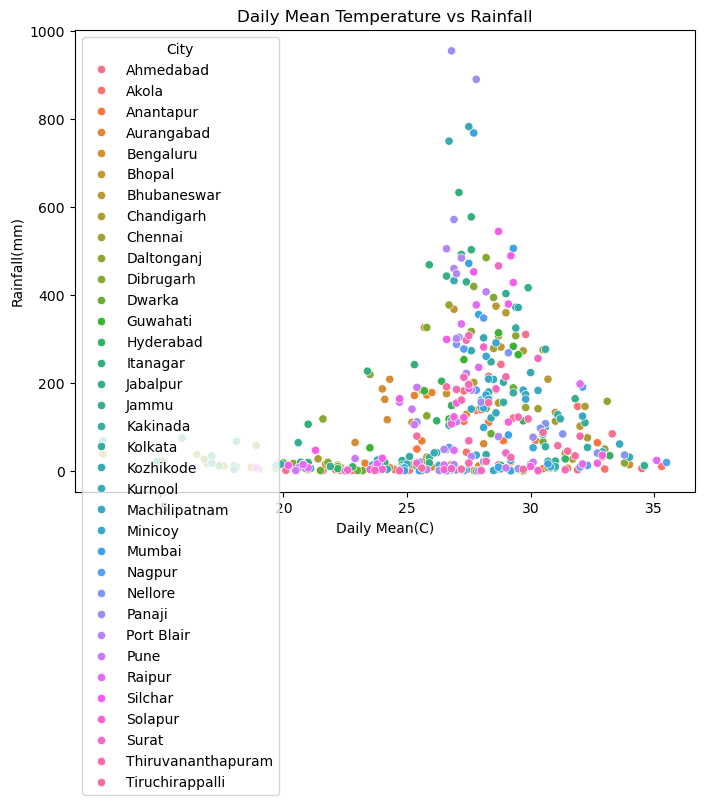

In [132]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Daily Mean(C)", y="Rainfall(mm)",hue='City')
plt.title("Daily Mean Temperature vs Rainfall")
plt.show()

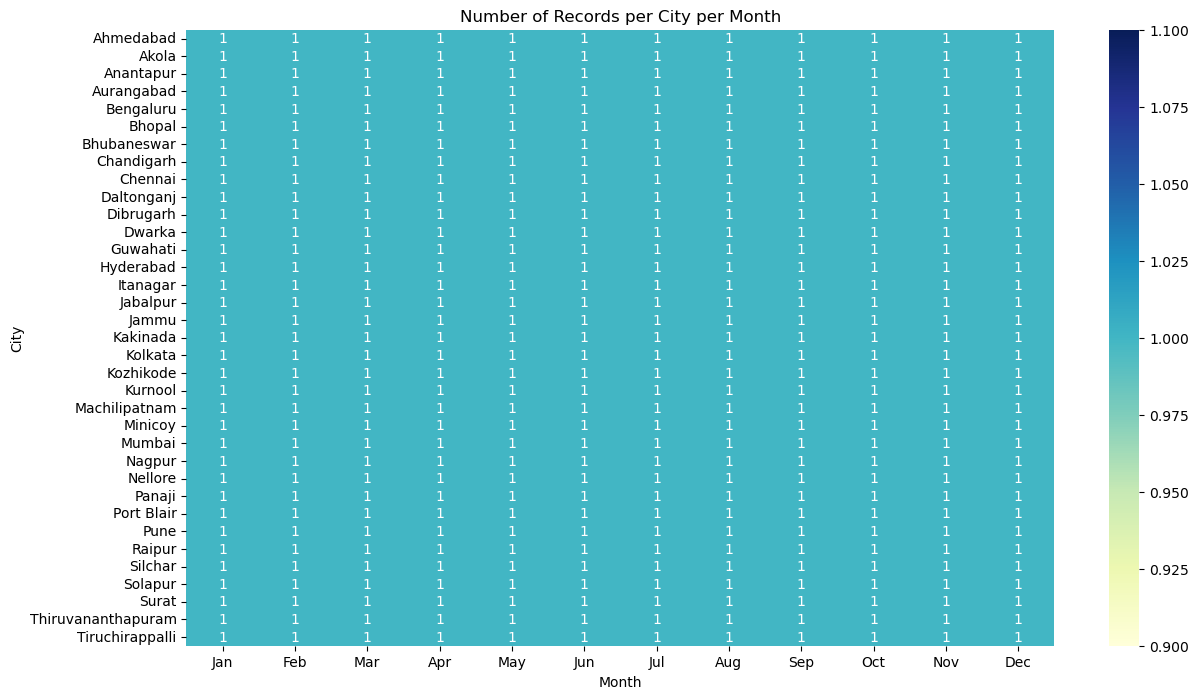

In [129]:
plt.figure(figsize=(14,8))
sns.heatmap(city_month_crosstab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Number of Records per City per Month")
plt.show()

In [130]:
pivot_rain = df.pivot_table(values="Rainfall(mm)", index="City", columns="Month", aggfunc="mean")
pivot_rain = pivot_rain[month_order]  
pivot_rain.head()

C:\Users\praha\AppData\Local\Temp\ipykernel_36560\1391694463.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_rain = df.pivot_table(values="Rainfall(mm)", index="City", columns="Month", aggfunc="mean")


Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City,,,,,,,,,,,,
Ahmedabad,1.2,0.6,1.1,2.5,5.5,84.3,310.1,242.2,120.2,13.1,1.9,0.9
Akola,10.6,5.5,14.2,4.2,10.1,146.8,215.0,181.8,137.7,42.5,11.8,3.1
Anantapur,3.0,1.2,5.0,32.0,64.1,69.2,68.7,110.2,139.1,112.8,49.8,8.5
Aurangabad,2.6,2.2,11.4,6.0,17.4,155.6,178.0,171.5,172.4,68.2,17.5,8.9
Bengaluru,1.6,7.1,14.7,61.7,128.7,110.3,116.4,162.7,208.3,186.4,64.5,15.4


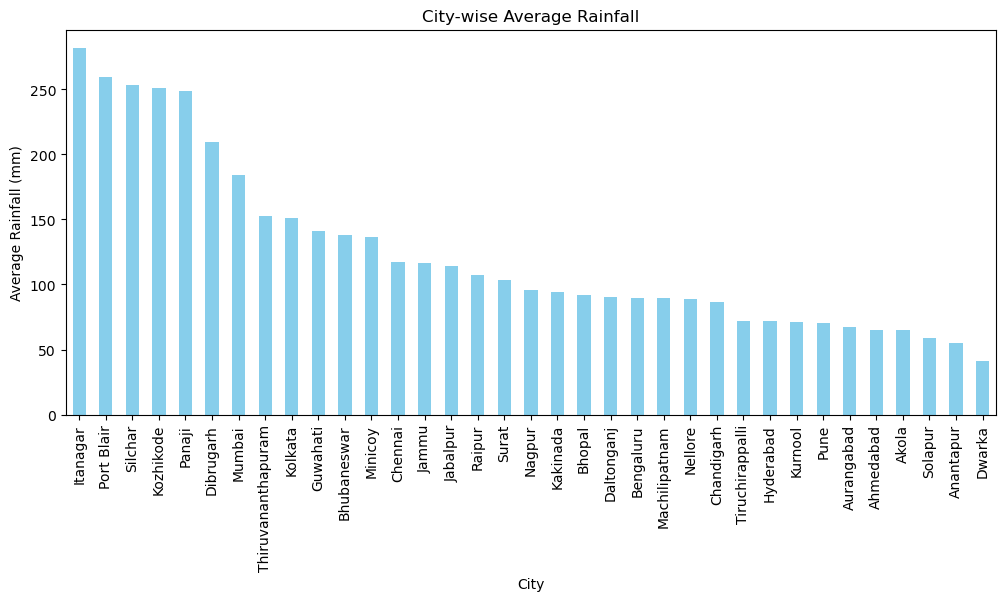

In [138]:
plt.figure(figsize=(12,5))
city_max["Rainfall(mm)"].sort_values(ascending=False).plot(kind="bar", color="skyblue")
plt.ylabel("Average Rainfall (mm)")
plt.title("City-wise Average Rainfall")
plt.xticks(rotation=90)
plt.show()

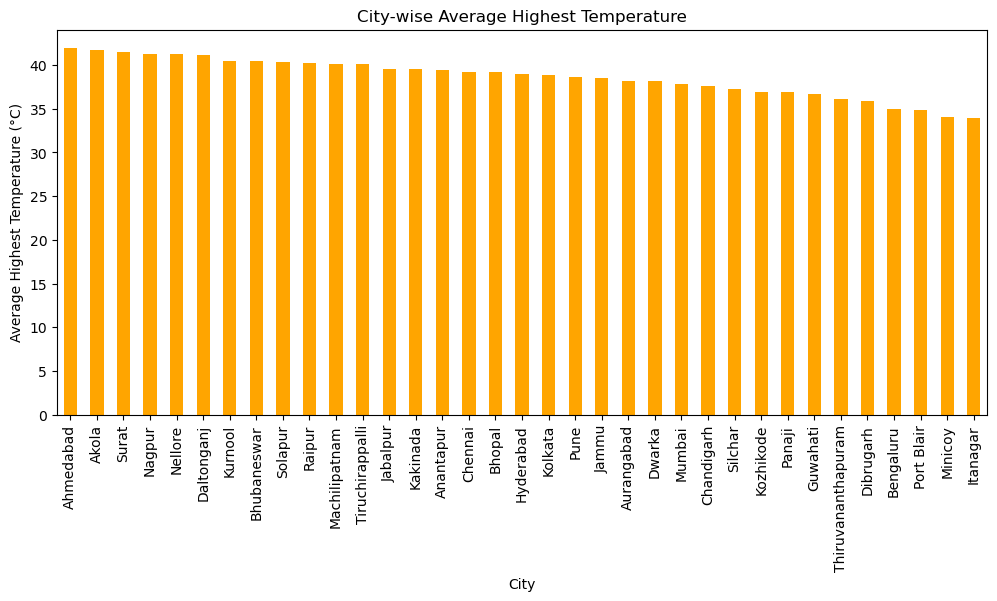

In [135]:
plt.figure(figsize=(12,5))
city_max["Highest_Temp(C)"].sort_values(ascending=False).plot(kind="bar", color="orange")
plt.ylabel("Average Highest Temperature (°C)")
plt.title("City-wise Average Highest Temperature")
plt.xticks(rotation=90)
plt.show()

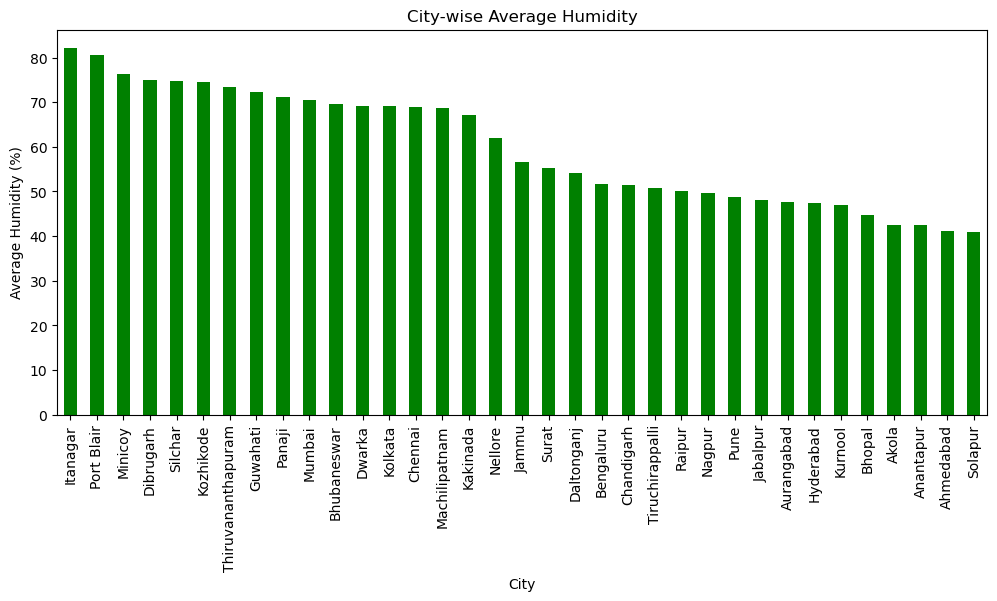

In [136]:
plt.figure(figsize=(12,5))
city_max["Humidity(%)"].sort_values(ascending=False).plot(kind="bar", color="green")
plt.ylabel("Average Humidity (%)")
plt.title("City-wise Average Humidity")
plt.xticks(rotation=90)
plt.show()

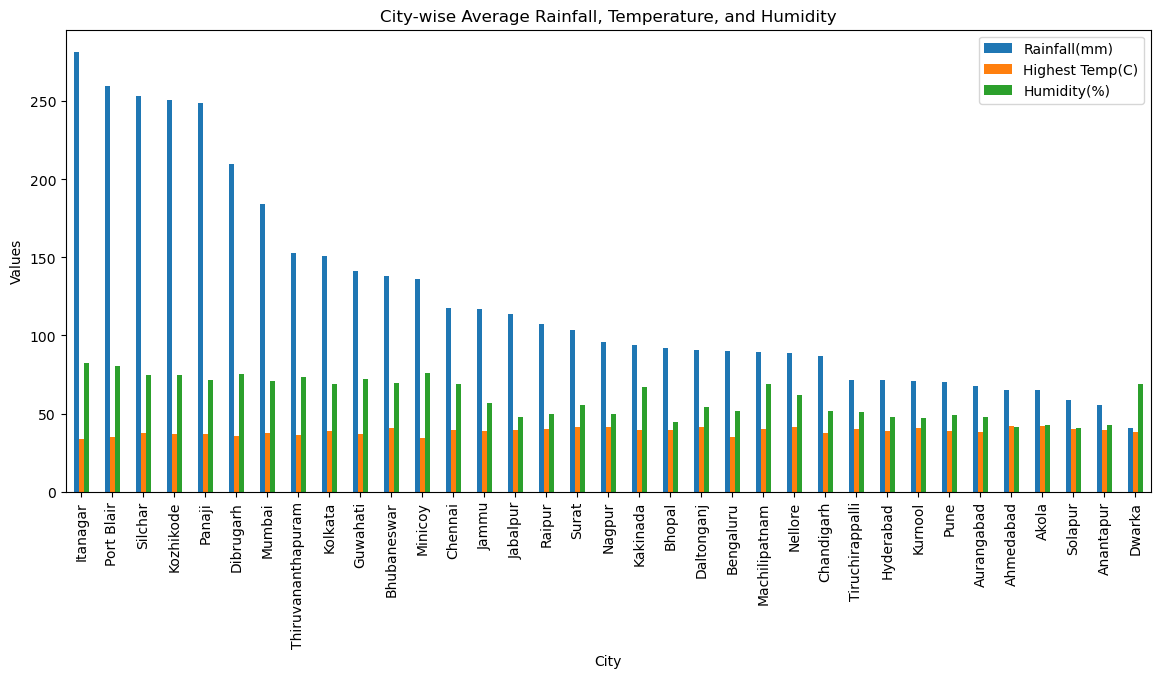

In [139]:
city_max_sorted = city_max.sort_values("Rainfall(mm)", ascending=False)
city_max_sorted.plot(kind="bar", figsize=(14,6))
plt.ylabel("Values")
plt.title("City-wise Average Rainfall, Temperature, and Humidity")
plt.xticks(rotation=90)
plt.legend(["Rainfall(mm)", "Highest Temp(C)", "Humidity(%)"])
plt.show()

In [142]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
pivot_rain = df.pivot_table(values="Rainfall(mm)", index="City", columns="Month", aggfunc="mean")
pivot_rain = pivot_rain[month_order]
pivot_rain.head()

C:\Users\praha\AppData\Local\Temp\ipykernel_36560\4177466498.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_rain = df.pivot_table(values="Rainfall(mm)", index="City", columns="Month", aggfunc="mean")


Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City,,,,,,,,,,,,
Ahmedabad,1.2,0.6,1.1,2.5,5.5,84.3,310.1,242.2,120.2,13.1,1.9,0.9
Akola,10.6,5.5,14.2,4.2,10.1,146.8,215.0,181.8,137.7,42.5,11.8,3.1
Anantapur,3.0,1.2,5.0,32.0,64.1,69.2,68.7,110.2,139.1,112.8,49.8,8.5
Aurangabad,2.6,2.2,11.4,6.0,17.4,155.6,178.0,171.5,172.4,68.2,17.5,8.9
Bengaluru,1.6,7.1,14.7,61.7,128.7,110.3,116.4,162.7,208.3,186.4,64.5,15.4


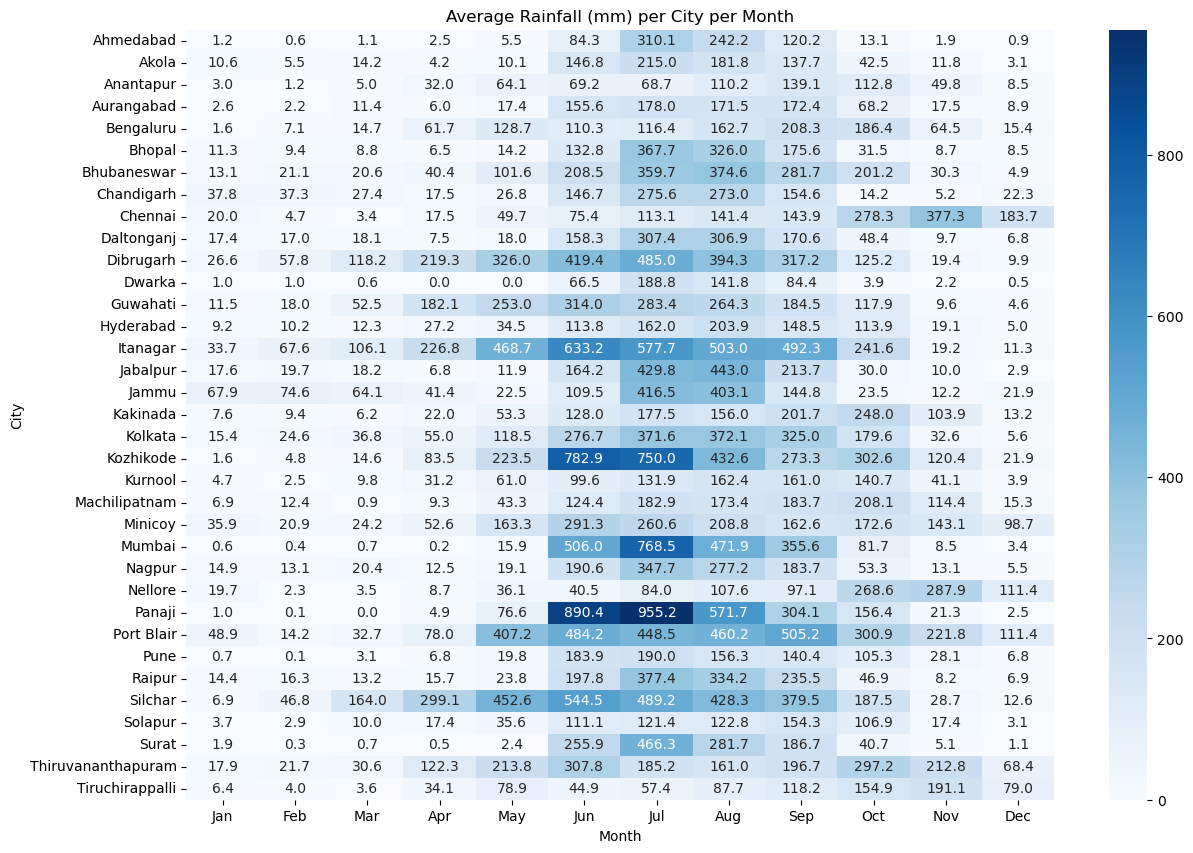

In [143]:
plt.figure(figsize=(14,10))
sns.heatmap(pivot_rain, annot=True, fmt=".1f", cmap="Blues")
plt.title("Average Rainfall (mm) per City per Month")
plt.ylabel("City")
plt.xlabel("Month")
plt.show()

C:\Users\praha\AppData\Local\Temp\ipykernel_35600\3543794848.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="City", order=df['City'].value_counts().index, palette="viridis")


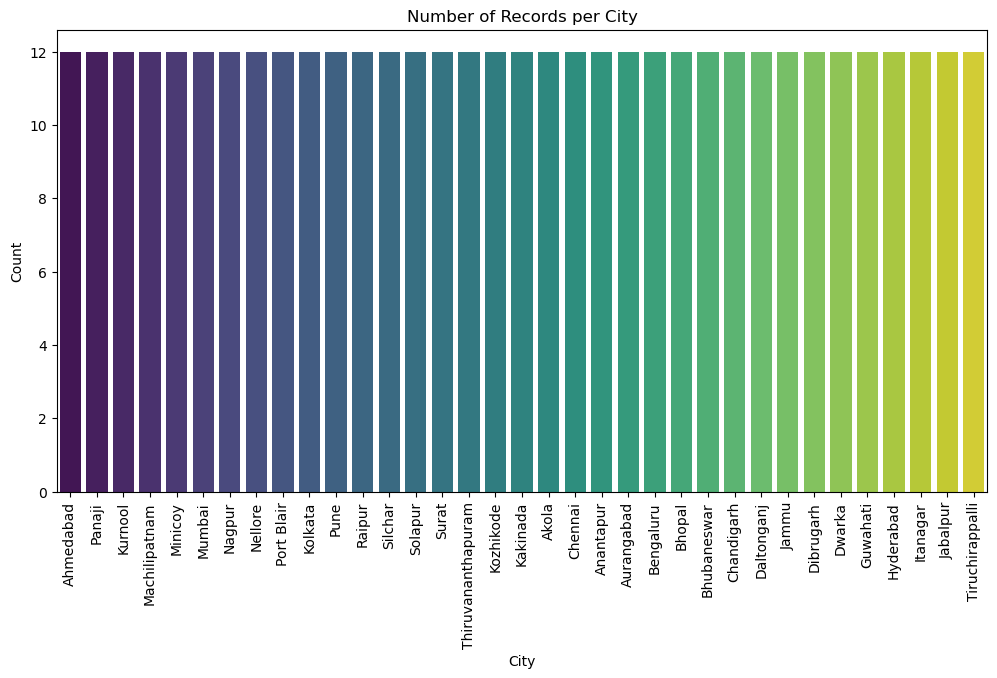

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="City", order=df['City'].value_counts().index, palette="viridis")
plt.xticks(rotation=90)
plt.title("Number of Records per City")
plt.ylabel("Count")
plt.xlabel("City")
plt.show()

C:\Users\praha\AppData\Local\Temp\ipykernel_35600\1393495255.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Month", order=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], palette="coolwarm")


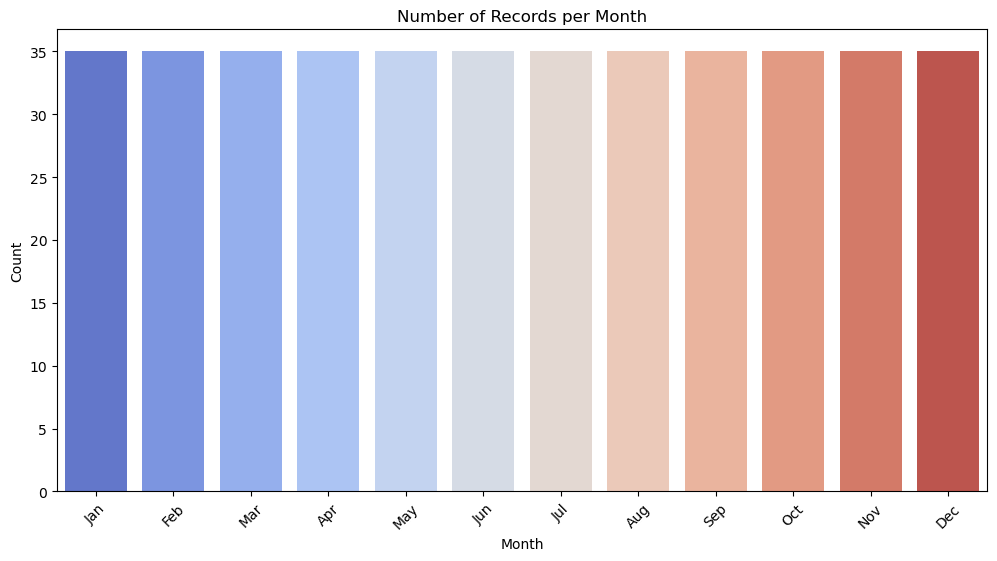

In [52]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Month", order=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Number of Records per Month")
plt.ylabel("Count")
plt.xlabel("Month")
plt.show()

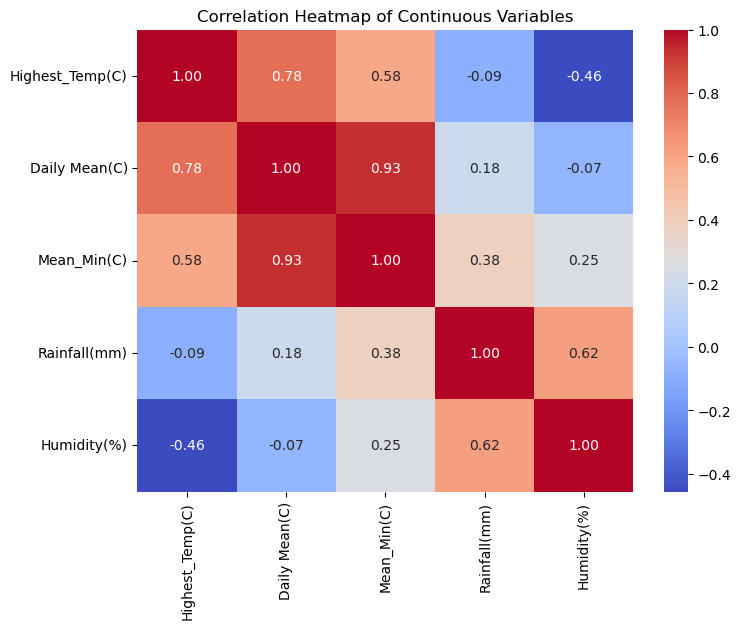

In [55]:
# Continuous variable correlation
corr = df[["Highest_Temp(C)", "Daily Mean(C)", "Mean_Min(C)", "Rainfall(mm)", "Humidity(%)"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Continuous Variables")
plt.show()

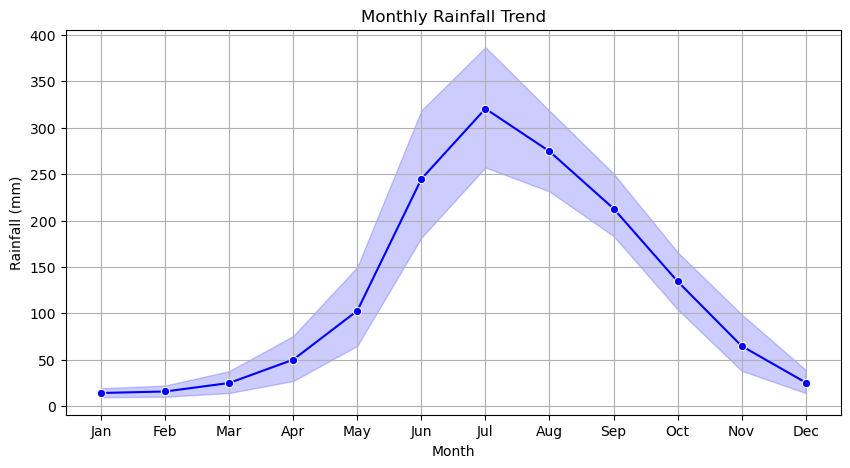

In [57]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Month", y="Rainfall(mm)", marker="o", color="blue")
plt.title("Monthly Rainfall Trend")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.show()

In [64]:

highest_rain_city = df.groupby("City")["Rainfall(mm)"].mean().idxmax()
highest_rain_value = df.groupby("City")["Rainfall(mm)"].mean().max()
lowest_rain_city = df.groupby("City")["Rainfall(mm)"].mean().idxmin()
lowest_rain_value = df.groupby("City")["Rainfall(mm)"].mean().min()
highest_temp_city = df.groupby("City")["Highest_Temp(C)"].mean().idxmax()
highest_temp_value = df.groupby("City")["Highest_Temp(C)"].mean().max()
lowest_temp_city = df.groupby("City")["Lowest_Temp(C)"].mean().idxmin()
lowest_temp_value = df.groupby("City")["Lowest_Temp(C)"].mean().min()

print(f"Highest Rainfall: {highest_rain_city} ({highest_rain_value:.2f} mm)")
print(f"Lowest Rainfall: {lowest_rain_city} ({lowest_rain_value:.2f} mm)")
print(f"Highest Temp: {highest_temp_city} ({highest_temp_value:.2f} °C)")
print(f"Lowest Temp: {lowest_temp_city} ({lowest_temp_value:.2f} °C)")
city_humidity = df.groupby("City")["Humidity(%)"].mean()
highest_humidity_city = city_humidity.idxmax()
highest_humidity_value = city_humidity.max()
lowest_humidity_city = city_humidity.idxmin()
lowest_humidity_value = city_humidity.min()

print(f"Highest Humidity: {highest_humidity_city} ({highest_humidity_value:.2f} %)")
print(f"Lowest Humidity: {lowest_humidity_city} ({lowest_humidity_value:.2f} %)")

Highest Rainfall: Itanagar (281.77 mm)
Lowest Rainfall: Dwarka (40.89 mm)
Highest Temp: Ahmedabad (41.97 °C)
Lowest Temp: Chandigarh (8.25 °C)
Highest Humidity: Itanagar (82.17 %)
Lowest Humidity: Solapur (41.00 %)
